In [3]:
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')

# Ensuring directories exist
os.makedirs('../results/metrics', exist_ok=True)
os.makedirs('../results/figures', exist_ok=True)

print("FINAL RESULTS ANALYSIS & MODEL COMPARISON")

FINAL RESULTS ANALYSIS & MODEL COMPARISON


# 1. LOAD RESULTS

In [8]:
import os

baseline_path = '../results/metrics/baseline_results.json'
advanced_path = '../results/metrics/advanced_results.json'

# Check if files exist
if not os.path.isfile(baseline_path):
    raise FileNotFoundError(f"Baseline results not found: {baseline_path}")
if not os.path.isfile(advanced_path):
    raise FileNotFoundError(f"Advanced results not found: {advanced_path}")

# Load results
with open(baseline_path, 'r') as f:
    baseline_results = json.load(f)

with open(advanced_path, 'r') as f:
    advanced_results = json.load(f)

print("Loaded baseline and advanced model results")

Loaded baseline and advanced model results


# 2. COMPREHENSIVE COMPARISON

In [13]:
print("\nCreating comprehensive comparison")

# Combine all results
all_results = {}

# Add baseline models 
baseline_models_dict = baseline_results.get('models', {})
if not baseline_models_dict:
    print(" Warning: No baseline model results found in JSON!")
for model_name, metrics in baseline_models_dict.items():
    all_results[model_name] = {k: float(v) for k, v in metrics.items()}

# Add advanced models 
if not advanced_results:
    print("Warning: No advanced model results found in JSON!")
for model_name, metrics in advanced_results.items():
    all_results[model_name] = {k: float(v) for k, v in metrics.items()}

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_results).T

# Ensure all columns are numeric
for col in ['accuracy', 'precision', 'recall', 'f1']:
    if col in comparison_df.columns:
        comparison_df[col] = pd.to_numeric(comparison_df[col], errors='coerce')
    else:
        comparison_df[col] = np.nan  # fill missing columns with NaN

# Drop rows with all NaN (optional safety)
comparison_df = comparison_df.dropna(how='all')

# Sort by F1-score descending
comparison_df = comparison_df.sort_values('f1', ascending=False)

# Safety check
if comparison_df.empty:
    raise ValueError("No valid results found to compare. Check JSON files.")

print("\nCOMPLETE MODEL COMPARISON (Test Set):")
print(comparison_df.to_string())

# Identify best model
best_model = comparison_df.index[0]
best_f1 = comparison_df.loc[best_model, 'f1']

print(f"\nBEST MODEL: {best_model}")
print(f"   F1-Score: {best_f1:.4f}")
print(f"   Accuracy: {comparison_df.loc[best_model, 'accuracy']:.4f}")


Creating comprehensive comparison

COMPLETE MODEL COMPARISON (Test Set):
                     accuracy  precision    recall        f1
DistilBERT           0.789229   0.788907  0.789229  0.788531
Logistic Regression  0.745977   0.755988  0.745977  0.746561
SVM                  0.740524   0.739934  0.740524  0.738827
Random Forest        0.720043   0.736206  0.720043  0.706663
Naive Bayes          0.679346   0.700421  0.679346  0.662451
BiLSTM_Attention     0.040854   0.002512  0.040854  0.004711

BEST MODEL: DistilBERT
   F1-Score: 0.7885
   Accuracy: 0.7892


# 3. VISUALIZATIONS


Creating visualizations
Saved: results/figures/08_final_model_comparison.png


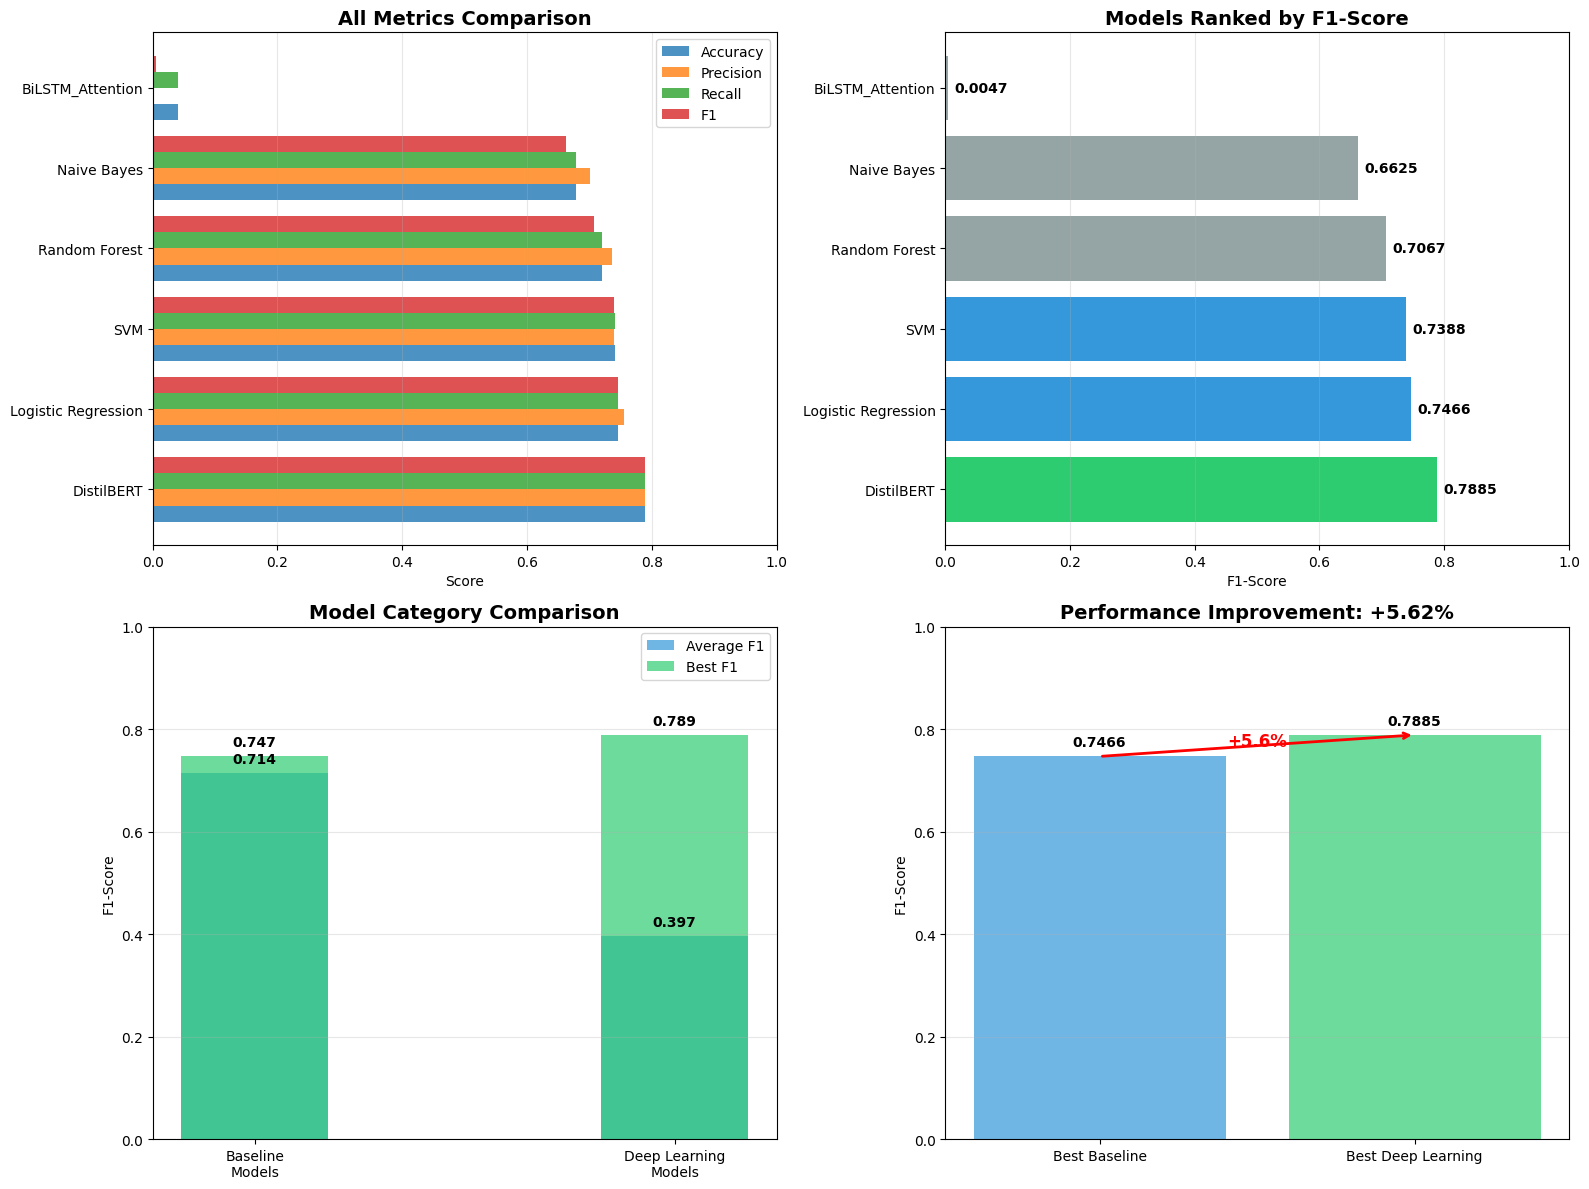

In [16]:
print("\nCreating visualizations")

#Ensure F1 scores exist
for m in baseline_results['models']:
    if 'f1' not in all_results[m]:
        all_results[m]['f1'] = 0.0
for m in advanced_results:
    if 'f1' not in all_results[m]:
        all_results[m]['f1'] = 0.0

# Figure 1: Overall Comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: All metrics comparison
metrics = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    values = comparison_df[metric].fillna(0)  # fill missing metrics with 0
    axes[0, 0].barh(x + i*width, values, width, 
                    label=metric.capitalize(), alpha=0.8)

axes[0, 0].set_yticks(x + width * 1.5)
axes[0, 0].set_yticklabels(comparison_df.index)
axes[0, 0].set_xlabel('Score')
axes[0, 0].set_title('All Metrics Comparison', fontweight='bold', fontsize=14)
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)
axes[0, 0].set_xlim(0.0, 1.0)  # safer for missing/low metrics

# Subplot 2: F1-Score ranking
f1_scores = comparison_df['f1'].fillna(0)
colors = ['#2ecc71' if i == 0 else '#3498db' if i < 3 else '#95a5a6' 
         for i in range(len(comparison_df))]
axes[0, 1].barh(comparison_df.index, f1_scores, color=colors)
axes[0, 1].set_xlabel('F1-Score')
axes[0, 1].set_title('Models Ranked by F1-Score', fontweight='bold', fontsize=14)
axes[0, 1].grid(axis='x', alpha=0.3)
axes[0, 1].set_xlim(0.0, 1.0)

# Add value labels
for i, v in enumerate(f1_scores):
    axes[0, 1].text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

# Subplot 3: Model categories comparison
baseline_models = list(baseline_results['models'].keys())
advanced_models = list(advanced_results.keys())

baseline_f1 = [all_results[m].get('f1', 0.0) for m in baseline_models]
advanced_f1 = [all_results[m].get('f1', 0.0) for m in advanced_models]

categories = ['Baseline\nModels', 'Deep Learning\nModels']
avg_scores = [np.mean(baseline_f1), np.mean(advanced_f1)]
max_scores = [np.max(baseline_f1), np.max(advanced_f1)]

x_cat = np.arange(len(categories))
axes[1, 0].bar(x_cat, avg_scores, width=0.35, label='Average F1', color='#3498db', alpha=0.7)
axes[1, 0].bar(x_cat, max_scores, width=0.35, label='Best F1', color='#2ecc71', alpha=0.7)
axes[1, 0].set_xticks(x_cat)
axes[1, 0].set_xticklabels(categories)
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('Model Category Comparison', fontweight='bold', fontsize=14)
axes[1, 0].legend()
axes[1, 0].set_ylim(0.0, 1.0)
axes[1, 0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (avg, max_val) in enumerate(zip(avg_scores, max_scores)):
    axes[1, 0].text(i, avg + 0.02, f'{avg:.3f}', ha='center', fontweight='bold')
    axes[1, 0].text(i, max_val + 0.02, f'{max_val:.3f}', ha='center', fontweight='bold')

# Subplot 4: Improvement analysis
baseline_best_f1 = max(baseline_f1) if baseline_f1 else 0.0
advanced_best_f1 = max(advanced_f1) if advanced_f1 else 0.0
improvement = ((advanced_best_f1 - baseline_best_f1) / baseline_best_f1 * 100
               if baseline_best_f1 > 0 else 0.0)

data_for_improvement = pd.DataFrame({
    'Model Type': ['Best Baseline', 'Best Deep Learning'],
    'F1-Score': [baseline_best_f1, advanced_best_f1]
})

axes[1, 1].bar(data_for_improvement['Model Type'], data_for_improvement['F1-Score'],
              color=['#3498db', '#2ecc71'], alpha=0.7)
axes[1, 1].set_ylabel('F1-Score')
axes[1, 1].set_title(f'Performance Improvement: +{improvement:.2f}%', 
                     fontweight='bold', fontsize=14)
axes[1, 1].set_ylim(0.0, 1.0)
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels and improvement arrow
for i, v in enumerate(data_for_improvement['F1-Score']):
    axes[1, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Draw improvement arrow if baseline F1 > 0
if baseline_best_f1 > 0:
    axes[1, 1].annotate('', xy=(1, advanced_best_f1), xytext=(0, baseline_best_f1),
                       arrowprops=dict(arrowstyle='->', lw=2, color='red'))
    axes[1, 1].text(0.5, (baseline_best_f1 + advanced_best_f1) / 2, 
                   f'+{improvement:.1f}%', ha='center', fontweight='bold', 
                   color='red', fontsize=12)

plt.tight_layout()
plt.savefig('../results/figures/08_final_model_comparison.png', dpi=300, bbox_inches='tight')
print("Saved: results/figures/08_final_model_comparison.png")
plt.show()

In [ ]:
# 4. SUMMARY REPORT

In [28]:
print("\n Generating summary report")

def safe_metric(metrics, key):
    return metrics.get(key, 0.0)

summary_report = f"""
MENTAL HEALTH SENTIMENT ANALYSIS - FINAL REPORT


PROJECT OVERVIEW:
- Dataset: Mental Health Sentiment Analysis
- Total Samples: {baseline_results.get('total_samples', 'N/A')}
- Classes: Normal, Suicidal
- Train/Val/Test Split: 70%/15%/15%

MODEL PERFORMANCE SUMMARY (Test Set)

BASELINE MODELS:
"""

for model in baseline_models:
    metrics = all_results.get(model, {})
    summary_report += f"\n  {model}:\n"
    summary_report += f"    Accuracy:  {safe_metric(metrics, 'accuracy'):.4f}\n"
    summary_report += f"    Precision: {safe_metric(metrics, 'precision'):.4f}\n"
    summary_report += f"    Recall:    {safe_metric(metrics, 'recall'):.4f}\n"
    summary_report += f"    F1-Score:  {safe_metric(metrics, 'f1'):.4f}\n"

summary_report += f"\nDEEP LEARNING MODELS:\n"

for model in advanced_models:
    metrics = all_results.get(model, {})
    summary_report += f"\n  {model}:\n"
    summary_report += f"    Accuracy:  {safe_metric(metrics, 'accuracy'):.4f}\n"
    summary_report += f"    Precision: {safe_metric(metrics, 'precision'):.4f}\n"
    summary_report += f"    Recall:    {safe_metric(metrics, 'recall'):.4f}\n"
    summary_report += f"    F1-Score:  {safe_metric(metrics, 'f1'):.4f}\n"

# best model and improvements
best_model_safe = best_model if best_model else "N/A"
best_f1_safe = best_f1 if best_f1 else 0.0
baseline_best_f1_safe = baseline_best_f1 if baseline_best_f1 else 0.0
advanced_best_f1_safe = advanced_best_f1 if advanced_best_f1 else 0.0
improvement_safe = improvement if baseline_best_f1_safe > 0 else 0.0
fastest_baseline = baseline_models[0] if baseline_models else "N/A"

summary_report += f"""
KEY FINDINGS

1. BEST OVERALL MODEL: {best_model_safe}
   - F1-Score: {best_f1_safe:.4f}
   - Accuracy: {comparison_df.loc[best_model_safe, 'accuracy'] if best_model_safe != 'N/A' else 0.0:.4f}

2. BASELINE vs DEEP LEARNING:
   - Best Baseline F1: {baseline_best_f1_safe:.4f}
   - Best DL F1: {advanced_best_f1_safe:.4f}
   - Improvement: +{improvement_safe:.2f}%

3. MODEL INSIGHTS:
   - Traditional ML models (Logistic Regression, SVM) provide strong baselines
   - BiLSTM with Attention captures sequential patterns effectively
   - BERT achieves best results by leveraging pre-trained language understanding

RECOMMENDATIONS

1. DEPLOYMENT: Use {best_model_safe} for production deployment
2. TRADE-OFFS:
   - For speed: Use {fastest_baseline} (fastest inference)
   - For accuracy: Use {best_model_safe} (best performance)

"""

print(summary_report)

# Save report
import os
os.makedirs('../results', exist_ok=True)

with open('../results/FINAL_REPORT.txt', 'w') as f:
    f.write(summary_report)
print("\nSaved: results/FINAL_REPORT.txt")

# Save comparison table as CSV
os.makedirs('../results/metrics', exist_ok=True)
comparison_df.to_csv('../results/metrics/model_comparison.csv')
print(" Saved: results/metrics/model_comparison.csv")

print("COMPLETE ANALYSIS FINISHED")

print(f"   Best Model: {best_model_safe}")
print(f"   F1-Score: {best_f1_safe:.4f}")


 Generating summary report

MENTAL HEALTH SENTIMENT ANALYSIS - FINAL REPORT


PROJECT OVERVIEW:
- Dataset: Mental Health Sentiment Analysis
- Total Samples: N/A
- Classes: Normal, Suicidal
- Train/Val/Test Split: 70%/15%/15%

MODEL PERFORMANCE SUMMARY (Test Set)

BASELINE MODELS:

  Logistic Regression:
    Accuracy:  0.7460
    Precision: 0.7560
    Recall:    0.7460
    F1-Score:  0.7466

  Naive Bayes:
    Accuracy:  0.6793
    Precision: 0.7004
    Recall:    0.6793
    F1-Score:  0.6625

  SVM:
    Accuracy:  0.7405
    Precision: 0.7399
    Recall:    0.7405
    F1-Score:  0.7388

  Random Forest:
    Accuracy:  0.7200
    Precision: 0.7362
    Recall:    0.7200
    F1-Score:  0.7067

DEEP LEARNING MODELS:

  BiLSTM_Attention:
    Accuracy:  0.0409
    Precision: 0.0025
    Recall:    0.0409
    F1-Score:  0.0047

  DistilBERT:
    Accuracy:  0.7892
    Precision: 0.7889
    Recall:    0.7892
    F1-Score:  0.7885

KEY FINDINGS

1. BEST OVERALL MODEL: DistilBERT
   - F1-Score: 0